# 1. Purpose

Test a small set of pre-declared business and engineering hypotheses about C-MAPSS FD001 degradation. The analysis asks which observable conditions distinguish terminal from non-terminal operation and which patterns could support maintenance prioritization. This is descriptive EDA only: no model, predictive metric, feature pipeline, or production threshold is created.

# 2. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "docs" / "data_strategy.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root")

REPO_ROOT = find_repository_root(Path.cwd().resolve())
TRAIN_PATH = REPO_ROOT / "data" / "raw" / "cmapss" / "train_FD001.txt"
print(f"Repository root located: {REPO_ROOT.name}")

Repository root located: industrial-predictive-maintenance-decision-intelligence


# 3. Load Validated Raw Data

The immutable FD001 training file is loaded using the schema validated on Day 9. RUL is not present in the raw predictors; it is derived later only as an outcome for retrospective analysis.

In [2]:
COLUMN_NAMES = (
    ["unit_number", "cycle"]
    + [f"operational_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)
df_raw = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None, names=COLUMN_NAMES)
assert df_raw.shape == (20631, 26)
assert df_raw[["unit_number", "cycle"]].duplicated().sum() == 0
print(f"Loaded {len(df_raw):,} immutable observations from {df_raw['unit_number'].nunique()} engines.")

Loaded 20,631 immutable observations from 100 engines.


# 4. Safe Feature Set

The primary NASA paper supplied in the archive maps the 21 sensor columns, in order, to the published C-MAPSS outputs. Variable channels are eligible for EDA. `unit_number` remains ID-only; seven constants, near-constant `sensor_6`, RUL, final cycle, future rows, and future-containing aggregates are excluded from predictive inputs.

In [3]:
SENSOR_METADATA = {
    "sensor_1": ("T2", "Fan-inlet total temperature", "°R"),
    "sensor_2": ("T24", "LPC-outlet total temperature", "°R"),
    "sensor_3": ("T30", "HPC-outlet total temperature", "°R"),
    "sensor_4": ("T50", "LPT-outlet total temperature", "°R"),
    "sensor_5": ("P2", "Fan-inlet pressure", "psia"),
    "sensor_6": ("P15", "Bypass-duct total pressure", "psia"),
    "sensor_7": ("P30", "HPC-outlet total pressure", "psia"),
    "sensor_8": ("Nf", "Physical fan speed", "rpm"),
    "sensor_9": ("Nc", "Physical core speed", "rpm"),
    "sensor_10": ("epr", "Engine pressure ratio", "dimensionless"),
    "sensor_11": ("Ps30", "HPC-outlet static pressure", "psia"),
    "sensor_12": ("phi", "Fuel-flow to Ps30 ratio", "pps/psi"),
    "sensor_13": ("NRf", "Corrected fan speed", "rpm"),
    "sensor_14": ("NRc", "Corrected core speed", "rpm"),
    "sensor_15": ("BPR", "Bypass ratio", "dimensionless"),
    "sensor_16": ("farB", "Burner fuel-air ratio", "dimensionless"),
    "sensor_17": ("htBleed", "Bleed enthalpy", "not stated"),
    "sensor_18": ("Nf_dmd", "Demanded fan speed", "rpm"),
    "sensor_19": ("PCNfR_dmd", "Demanded corrected fan speed", "rpm"),
    "sensor_20": ("W31", "HPT coolant bleed", "lbm/s"),
    "sensor_21": ("W32", "LPT coolant bleed", "lbm/s"),
}
REMOVED_FEATURES = {"operational_setting_3", "sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"}
SAFE_FEATURES = ["cycle", "operational_setting_1", "operational_setting_2"] + [
    f"sensor_{i}" for i in [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]
]
assert not REMOVED_FEATURES.intersection(SAFE_FEATURES)
print("Safe EDA inputs:", SAFE_FEATURES)
print("Excluded inputs:", sorted(REMOVED_FEATURES))

Safe EDA inputs: ['cycle', 'operational_setting_1', 'operational_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Excluded inputs: ['operational_setting_3', 'sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5', 'sensor_6']


# 5. Hypotheses Before Analysis

These hypotheses were fixed before producing comparisons or plots:

1. **Operating-regime stability:** FD001's operating settings do not materially distinguish terminal from non-terminal observations because the subset represents one operating condition.
2. **Thermal degradation:** T24, T30, and T50 shift progressively as engines approach failure.
3. **Pressure and flow degradation:** Ps30, phi, P30, and coolant-bleed channels change coherently near failure.
4. **Interaction effects:** Three domain-related pairs provide more lifecycle separation jointly than either condition alone.
5. **Engine heterogeneity:** Engine lifetimes vary enough that cycle age alone cannot define one reliable intervention point.
6. **Extreme conditions and sample sufficiency:** Terminal observations concentrate in extreme sensor bands, but event and engine counts constrain confidence.
7. **Decision relevance:** Concordant, observable degradation signals are more useful for inspection priority than operating settings or a single universal age rule.

`RUL`, terminal status, and the descriptive final-30-cycle band are outcomes used only to compare states. The 30-cycle band is not an approved prediction horizon, feature, alert threshold, or economic policy.

# 6. Hypothesis 1

## Hypothesis 1 — Operating-Regime Stability

### Business Rationale
Operating policy is actionable only if setting differences are associated with deteriorating condition.

### Analytical Question
Do operational settings 1 and 2 materially differ between terminal and non-terminal observations?

### Analysis
Compare counts, central tendency, dispersion, and standardized mean differences.

In [4]:
df = df_raw.copy()
df["rul"] = df.groupby("unit_number")["cycle"].transform("max") - df["cycle"]
df["is_terminal"] = df["rul"].eq(0)
df["retrospective_stage"] = pd.cut(
    df["rul"], [-1, 30, 60, 125, np.inf], labels=["final_30", "31_60", "61_125", "over_125"]
)
setting_features = ["operational_setting_1", "operational_setting_2"]
setting_comparison = df.groupby("is_terminal")[setting_features].agg(["count", "mean", "median", "std"])
setting_effect = pd.DataFrame({
    "terminal_minus_nonterminal_mean": df.groupby("is_terminal")[setting_features].mean().diff().iloc[-1],
    "standardized_mean_difference": df.groupby("is_terminal")[setting_features].mean().diff().iloc[-1] / df[setting_features].std(),
})
display(setting_comparison)
display(setting_effect)

operational_setting_1                         \
                            count    mean  median    std   
is_terminal                                                
False                       20531 -0.0000 -0.0000 0.0022   
True                          100  0.0000  0.0002 0.0023   

            operational_setting_2                         
                            count    mean  median    std  
is_terminal                                               
False                       20531  0.0000  0.0000 0.0003  
True                          100 -0.0001 -0.0001 0.0003

,terminal_minus_nonterminal_mean,standardized_mean_difference
operational_setting_1,0.0001,0.0243
operational_setting_2,-0.0001,-0.1795


### Result
Terminal versus non-terminal standardized mean differences are approximately 0.02 for setting 1 and -0.18 for setting 2; medians are effectively unchanged.

### Interpretation
The observed settings do not materially separate terminal operation in FD001. This is consistent with a one-condition subset, not evidence that operating conditions never matter.

### Modeling Implication
Retain settings 1 and 2 for protocol completeness, but expect limited standalone discrimination in FD001.

### Business Implication
The data does not support changing operating policy based on these settings.

### Limitations
Setting units and exact ordering remain less explicit than sensor definitions, and FD001 excludes multi-regime operation.

# 7. Hypothesis 2

## Hypothesis 2 — Thermal Degradation

### Business Rationale
Consistent temperature drift could provide an observable condition signal before failure and support earlier inspection.

### Analytical Question
Do T24, T30, and T50 change coherently from earlier-life to final-cycle observations?

### Analysis
Compare terminal/non-terminal distributions and medians across retrospective RUL bands.

sensor_2                                            sensor_3  \
               count     mean   median    std      min      max    count   
is_terminal                                                                
False          20531 642.6759 642.6400 0.4955 641.2100 644.5300    20531   
True             100 643.7218 643.7150 0.2877 643.0200 644.5300      100   

                                                               sensor_4  \
                  mean     median    std        min        max    count   
is_terminal                                                               
False       1,590.4648 1,590.0600 6.0811 1,571.0400 1,616.9100    20531   
True        1,602.4990 1,601.8700 4.3730 1,592.4500 1,612.6300      100   

                                                                
                  mean     median    std        min        max  
is_terminal                                                     
False       1,408.8269 1,407.9700 8.8868 1,382.2500 1,438.5100  
True        1,430.8732 1,431.4100 3.9294 1,421.4100 1,441.4900

median                             sample          \
                    sensor_2   sensor_3   sensor_4 observations engines   
retrospective_stage                                                       
over_125            642.4000 1,587.2400 1,403.0400         8031     100   
61_125              642.6000 1,589.4700 1,407.3600         6500     100   
31_60               642.9200 1,593.2700 1,413.7900         3000     100   
final_30            643.3700 1,598.6400 1,422.8000         3100     100   

                                   
                    terminal_rows  
retrospective_stage                
over_125                        0  
61_125                          0  
31_60                           0  
final_30                      100

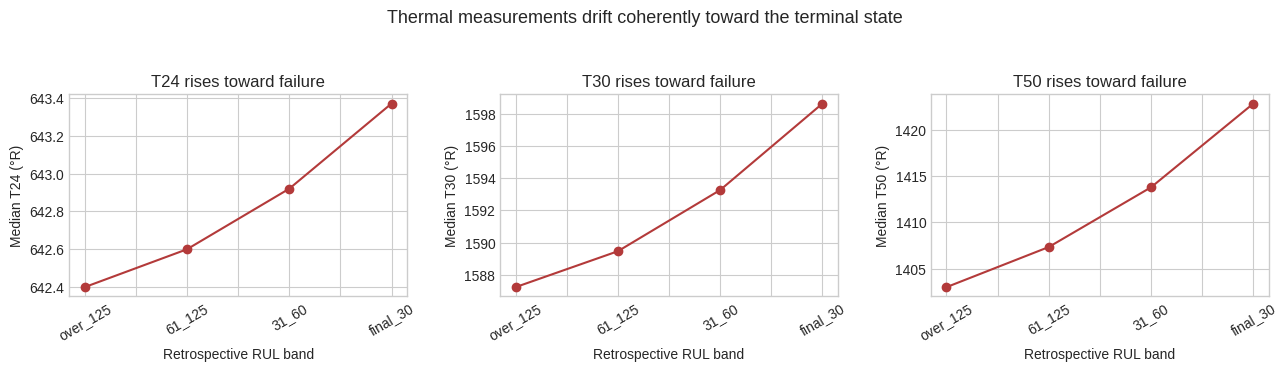

In [5]:
thermal_features = ["sensor_2", "sensor_3", "sensor_4"]
thermal_terminal = df.groupby("is_terminal")[thermal_features].agg(["count", "mean", "median", "std", "min", "max"])
stage_order = ["over_125", "61_125", "31_60", "final_30"]
thermal_by_stage = df.groupby("retrospective_stage", observed=True)[thermal_features].median().reindex(stage_order)
stage_counts = df.groupby("retrospective_stage", observed=True).agg(observations=("rul", "size"), engines=("unit_number", "nunique"), terminal_rows=("is_terminal", "sum")).reindex(stage_order)
display(thermal_terminal)
display(pd.concat({"median": thermal_by_stage, "sample": stage_counts}, axis=1))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for axis, feature in zip(axes, thermal_features):
    label, description, unit = SENSOR_METADATA[feature]
    thermal_by_stage[feature].plot(marker="o", ax=axis, color="#b33a3a")
    axis.set_title(f"{label} rises toward failure")
    axis.set_xlabel("Retrospective RUL band")
    axis.set_ylabel(f"Median {label} ({unit})")
    axis.tick_params(axis="x", rotation=30)
fig.suptitle("Thermal measurements drift coherently toward the terminal state", y=1.05, fontsize=13)
fig.tight_layout()
plt.show()

### Result
Median T24/T30/T50 rise from 642.40/1,587.24/1,403.04 °R at more than 125 cycles remaining to 643.37/1,598.64/1,422.80 °R in the retrospective final-30 band. Each band contains all 100 engines; the final-30 band contains 3,100 rows.

### Interpretation
A coherent thermal signature is associated with proximity to simulated failure. The multi-channel direction is more persuasive than an isolated sensor shift.

### Modeling Implication
T24, T30, and T50 are priority candidate predictors; future validation should test whether their trajectories generalize to held-out engines.

### Business Implication
Rising temperatures across multiple engine locations could justify higher inspection priority, subject to validated alert logic.

### Limitations
RUL bands use future failure time for retrospective comparison only, and repeated rows within engines are not independent.

# 8. Hypothesis 3

## Hypothesis 3 — Pressure and Flow Degradation

### Business Rationale
Pressure and flow changes may reflect loss of component health and provide complementary evidence to temperature drift.

### Analytical Question
Do Ps30, phi, and coolant-bleed flows move consistently as RUL declines?

### Analysis
Compare terminal/non-terminal summaries and lifecycle-band medians for selected physical channels.

sensor_11                                        sensor_12  \
                count    mean  median    std     min     max     count   
is_terminal                                                              
False           20531 47.5381 47.5100 0.2639 46.8500 48.4800     20531   
True              100 48.1798 48.1750 0.1194 47.8900 48.5300       100   

                                                       sensor_20          \
                mean   median    std      min      max     count    mean   
is_terminal                                                                
False       521.4220 521.4800 0.7288 518.6900 523.3800     20531 38.8183   
True        519.6715 519.6800 0.3711 518.8300 520.5600       100 38.4022   

                                           sensor_21                         \
             median    std     min     max     count    mean  median    std   
is_terminal                                                                   
False       38.8300 0.1787 38.1400 39.4300     20531 23.2909 23.2987 0.1072   
True        38.4000 0.1005 38.1900 38.6500       100 23.0534 23.0362 0.0656   

                             
                min     max  
is_terminal                  
False       22.8942 23.6184  
True        22.9071 23.2228

,sensor_11,sensor_12,sensor_20,sensor_21
retrospective_stage,,,,
over_125,47.3600,521.8900,38.9300,23.3551
61_125,47.4900,521.5500,38.8500,23.3076
31_60,47.6850,521.0100,38.7300,23.2378
final_30,47.9700,520.2900,38.5600,23.1332


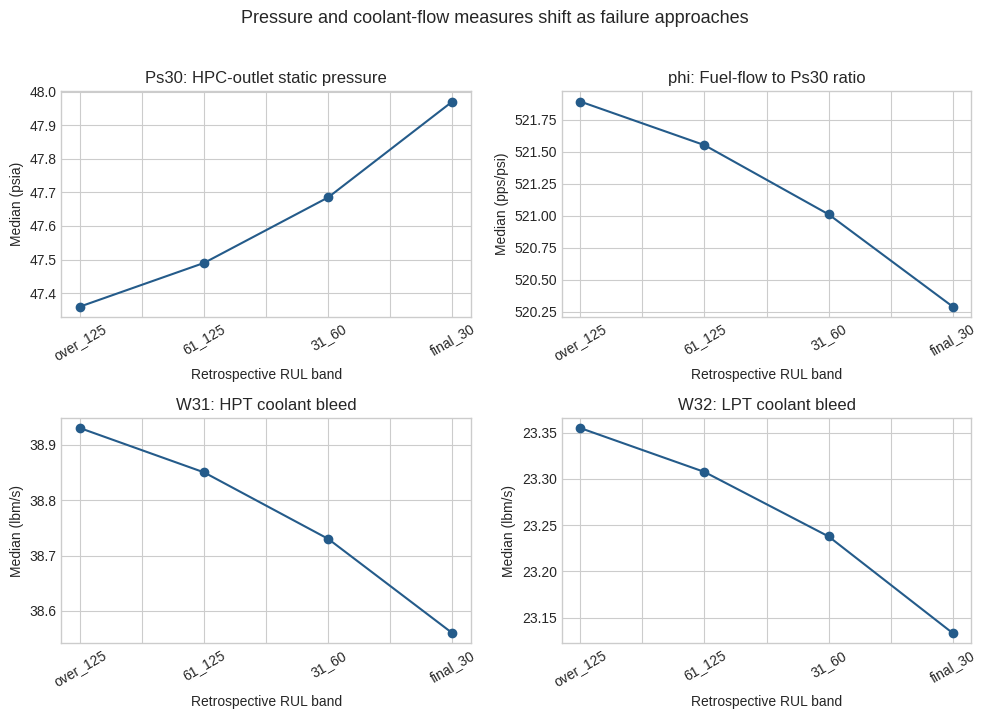

In [6]:
pressure_flow_features = ["sensor_11", "sensor_12", "sensor_20", "sensor_21"]
pressure_flow_terminal = df.groupby("is_terminal")[pressure_flow_features].agg(["count", "mean", "median", "std", "min", "max"])
pressure_flow_by_stage = df.groupby("retrospective_stage", observed=True)[pressure_flow_features].median().reindex(stage_order)
display(pressure_flow_terminal)
display(pressure_flow_by_stage)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for axis, feature in zip(axes.flat, pressure_flow_features):
    label, description, unit = SENSOR_METADATA[feature]
    pressure_flow_by_stage[feature].plot(marker="o", ax=axis, color="#245b8a")
    axis.set_title(f"{label}: {description}")
    axis.set_xlabel("Retrospective RUL band")
    axis.set_ylabel(f"Median ({unit})")
    axis.tick_params(axis="x", rotation=30)
fig.suptitle("Pressure and coolant-flow measures shift as failure approaches", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

### Result
From the over-125 to final-30 bands, median Ps30 rises from 47.36 to 47.97 psia while phi falls from 521.89 to 520.29 pps/psi, W31 falls from 38.93 to 38.56 lbm/s, and W32 falls from 23.36 to 23.13 lbm/s. Terminal-versus-non-terminal standardized differences exceed two dataset standard deviations for each channel.

### Interpretation
Pressure and flow measures provide a second, coherent degradation family associated with failure proximity.

### Modeling Implication
These channels should be evaluated jointly with temperatures under engine-disjoint validation rather than selected from row-level separation alone.

### Business Implication
Concordant thermal and flow deterioration could strengthen inspection priority and reduce reliance on a single noisy reading.

### Limitations
The simulation's single fault mode may make these trajectories more orderly than real plant telemetry.

# 9. Hypothesis 4

## Hypothesis 4 — Coordinated Interaction Effects

### Business Rationale
Maintenance teams should place more confidence in mutually reinforcing physical signals than in one extreme measurement.

### Analytical Question
Do three pre-specified sensor pairs identify late-life operation more clearly when both conditions occur together?

### Analysis
Use descriptive upper/lower quartile conditions for T30 + Ps30, T50 + phi, and W31 + W32. Compare counts, terminal rows, and final-30 rows across both/one/neither groups.

In [7]:
def condition(series: pd.Series, direction: str) -> tuple[pd.Series, float]:
    quantile = 0.75 if direction == "high" else 0.25
    cutoff = series.quantile(quantile)
    mask = series.ge(cutoff) if direction == "high" else series.le(cutoff)
    return mask, cutoff

def interaction_summary(frame, feature_a, direction_a, feature_b, direction_b, name):
    mask_a, cutoff_a = condition(frame[feature_a], direction_a)
    mask_b, cutoff_b = condition(frame[feature_b], direction_b)
    groups = pd.Series(np.select(
        [mask_a & mask_b, mask_a & ~mask_b, ~mask_a & mask_b],
        ["both", "A_only", "B_only"], default="neither"
    ), index=frame.index)
    result = frame.assign(interaction_group=groups, in_final_30=frame["rul"].le(30)).groupby("interaction_group").agg(
        observations=("is_terminal", "size"), engines=("unit_number", "nunique"),
        terminal_failures=("is_terminal", "sum"), terminal_rate=("is_terminal", "mean"),
        final_30_rows=("in_final_30", "sum"), final_30_rate=("in_final_30", "mean"),
    ).reindex(["both", "A_only", "B_only", "neither"])
    result.insert(0, "interaction", name)
    result.insert(1, "cutoffs", f"{feature_a} {direction_a} {cutoff_a:.4f}; {feature_b} {direction_b} {cutoff_b:.4f}")
    return result.reset_index(names="group")

interaction_tables = [
    interaction_summary(df, "sensor_3", "high", "sensor_11", "high", "High T30 + high Ps30"),
    interaction_summary(df, "sensor_4", "high", "sensor_12", "low", "High T50 + low phi"),
    interaction_summary(df, "sensor_20", "low", "sensor_21", "low", "Low W31 + low W32"),
]
interaction_results = pd.concat(interaction_tables, ignore_index=True)
display(interaction_results)

,group,interaction,cutoffs,observations,engines,terminal_failures,terminal_rate,final_30_rows,final_30_rate
0,both,High T30 + high Ps30,sensor_3 high 1594.3800; sensor_11 high 47.7000,3444,100,97,0.0282,2437,0.7076
1,A_only,High T30 + high Ps30,sensor_3 high 1594.3800; sensor_11 high 47.7000,1718,100,0,0.0000,115,0.0669
2,B_only,High T30 + high Ps30,sensor_3 high 1594.3800; sensor_11 high 47.7000,1868,100,3,0.0016,474,0.2537
3,neither,High T30 + high Ps30,sensor_3 high 1594.3800; sensor_11 high 47.7000,13601,100,0,0.0000,74,0.0054
4,both,High T50 + low phi,sensor_4 high 1414.5550; sensor_12 low 520.9600,3859,100,100,0.0259,2661,0.6896
5,A_only,High T50 + low phi,sensor_4 high 1414.5550; sensor_12 low 520.9600,1299,100,0,0.0000,199,0.1532
6,B_only,High T50 + low phi,sensor_4 high 1414.5550; sensor_12 low 520.9600,1383,98,0,0.0000,156,0.1128
7,neither,High T50 + low phi,sensor_4 high 1414.5550; sensor_12 low 520.9600,14090,100,0,0.0000,84,0.0060
8,both,Low W31 + low W32,sensor_20 low 38.7000; sensor_21 low 23.2218,3442,100,99,0.0288,2428,0.7054
9,A_only,Low W31 + low W32,sensor_20 low 38.7000; sensor_21 low 23.2218,1838,100,1,0.0005,272,0.1480


### Result
The `both` groups contain 3,442–3,859 observations across all 100 engines. Their retrospective final-30 rates are 68.96–70.76%, versus 0.54–1.00% when neither condition holds. High T50 + low phi captures 2,661 of 3,100 final-30 rows; low W31 + low W32 captures 2,428; high T30 + high Ps30 captures 2,437.

### Interpretation
The joint states add descriptive separation beyond either condition alone, supporting multi-signal rather than single-threshold reasoning.

### Modeling Implication
Future models may learn these relationships, but explicit interaction features are not created today. Validation must recompute any descriptive cutoffs using training folds only.

### Business Implication
Concordant deterioration could form an interpretable review rule for escalating inspection priority, pending out-of-sample validation and capacity design.

### Limitations
Quartiles are exploratory, in-sample cutoffs; final-30 is retrospective and is not the approved horizon `H`.

# 10. Hypothesis 5

## Hypothesis 5 — Engine-Lifetime Heterogeneity

### Business Rationale
A universal age rule can misallocate maintenance if otherwise similar assets fail at materially different ages.

### Analytical Question
How widely do engine lifetimes vary, and how does terminal prevalence differ across observed cycle-age segments?

### Analysis
Summarize per-engine final cycles retrospectively and show counts plus terminal rates across cycle-age quartiles. Final cycle is never used as an input.

,failure_cycle
count,100.0000
mean,206.3100
std,46.3427
min,128.0000
25%,177.0000
50%,199.0000
75%,229.2500
max,362.0000


,observations,engines,terminal_failures,terminal_rate
cycle_age_quartile,,,,
"(0.999, 52.0]",5200,100,0,0.0000
"(52.0, 104.0]",5200,100,0,0.0000
"(104.0, 156.0]",5081,100,13,0.0026
"(156.0, 362.0]",5150,87,87,0.0169


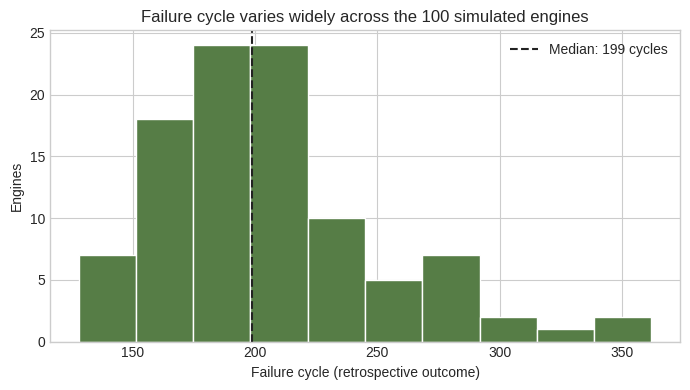

In [8]:
engine_lifetime = df.groupby("unit_number")["cycle"].max().rename("failure_cycle")
lifetime_summary = engine_lifetime.describe()
df["cycle_age_quartile"] = pd.qcut(df["cycle"], 4, duplicates="drop")
age_segment_summary = df.groupby("cycle_age_quartile", observed=True).agg(
    observations=("is_terminal", "size"), engines=("unit_number", "nunique"),
    terminal_failures=("is_terminal", "sum"), terminal_rate=("is_terminal", "mean"),
)
display(lifetime_summary.to_frame())
display(age_segment_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(engine_lifetime, bins=10, color="#567d46", edgecolor="white")
ax.axvline(engine_lifetime.median(), color="#222222", linestyle="--", label=f"Median: {engine_lifetime.median():.0f} cycles")
ax.set_title("Failure cycle varies widely across the 100 simulated engines")
ax.set_xlabel("Failure cycle (retrospective outcome)")
ax.set_ylabel("Engines")
ax.legend()
fig.tight_layout()
plt.show()

### Result
Failure cycles range from 128 to 362, with a median of 199 and standard deviation of 46.34 cycles. The oldest row-level age quartile contains 87 engines and 87 terminal rows; 13 shorter-lived engines fail in the preceding quartile.

### Interpretation
Chronological age is associated with failure but does not identify one universal failure age. Survivorship also changes the engine mix at older cycles.

### Modeling Implication
Keep `cycle` as an available predictor, compare against an age-only baseline later, and require engine-disjoint validation.

### Business Implication
Fixed age replacement alone may be too early for some assets and too late for others; condition evidence should refine priority.

### Limitations
Final-cycle segmentation is retrospective, and observed lifetime variation comes from simulation assumptions rather than client assets.

# 11. Optional Hypothesis 6

## Hypothesis 6 — Extreme Conditions and Sample Sufficiency

### Business Rationale
Extreme sensor bands are easy to communicate, but a high rate without adequate event and engine counts can be misleading.

### Analytical Question
Are terminal observations concentrated in the risk-direction decile of T50, Ps30, and phi, and are those segments adequately represented?

### Analysis
Create separate descriptive deciles for each channel and report observations, engines, terminal counts, and rates.

,feature,risk_direction,decile,observations,engines,terminal_failures,terminal_rate
0,sensor_4,high,10,2062,100,98,0.0475
1,sensor_11,high,10,1982,100,99,0.0499
2,sensor_12,low,1,2080,100,97,0.0466


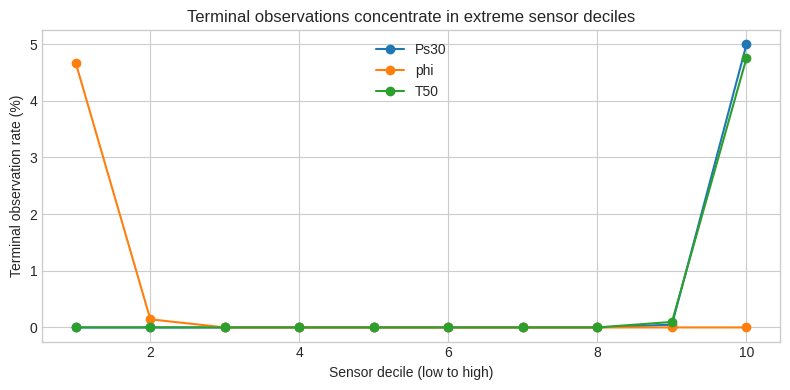

In [9]:
extreme_features = {"sensor_4": "high", "sensor_11": "high", "sensor_12": "low"}
decile_tables = []
for feature, risk_direction in extreme_features.items():
    decile = pd.qcut(df[feature], 10, labels=False, duplicates="drop") + 1
    table = df.assign(decile=decile).groupby("decile", observed=True).agg(
        observations=("is_terminal", "size"), engines=("unit_number", "nunique"),
        terminal_failures=("is_terminal", "sum"), terminal_rate=("is_terminal", "mean"),
    ).reset_index()
    table.insert(0, "feature", feature)
    table.insert(1, "risk_direction", risk_direction)
    decile_tables.append(table)
decile_results = pd.concat(decile_tables, ignore_index=True)
risk_deciles = pd.concat([
    table.tail(1) if direction == "high" else table.head(1)
    for table, direction in zip(decile_tables, extreme_features.values())
], ignore_index=True)
display(risk_deciles)

fig, ax = plt.subplots(figsize=(8, 4))
for feature, group in decile_results.groupby("feature"):
    label = SENSOR_METADATA[feature][0]
    ax.plot(group["decile"], 100 * group["terminal_rate"], marker="o", label=label)
ax.set_title("Terminal observations concentrate in extreme sensor deciles")
ax.set_xlabel("Sensor decile (low to high)")
ax.set_ylabel("Terminal observation rate (%)")
ax.legend()
fig.tight_layout()
plt.show()

### Result
The highest T50 decile contains 2,062 rows, all 100 engines, and 98 of 100 terminal observations (4.75% terminal rate). The highest Ps30 decile contains 1,982 rows and 99 terminal observations (5.00%); the lowest phi decile contains 2,080 rows and 97 terminal observations (4.66%).

### Interpretation
Extremes strongly concentrate terminal states and are not driven by a tiny machine segment. However, only 100 independent terminal events exist, and repeated rows inflate apparent sample size.

### Modeling Implication
Retain continuous values; do not convert these in-sample deciles into fixed features or alert rules. Evaluate calibration and engine-level generalization later.

### Business Implication
Extreme readings could raise inspection priority, but should be corroborated by multiple channels and capacity-aware policy.

### Limitations
Deciles are data-relative, not engineering limits; terminal prevalence is not the same as future failure probability.

# 12. Optional Hypothesis 7

## Hypothesis 7 — Decision Relevance

### Business Rationale
A pattern matters only if it can validly inform risk estimation, operating action, or maintenance allocation.

### Analytical Question
Which supported findings are predictive, actionable, and capable of changing maintenance priority?

### Analysis
Classify the evidence from Hypotheses 1–6 using explicit decision criteria.

In [10]:
actionability = pd.DataFrame([
    {"finding": "Coherent thermal, pressure, and flow drift", "predictive": "Yes", "actionable": "Indirectly", "decision_relevant": "Yes", "evidence_strength": "HIGH"},
    {"finding": "Joint sensor states separate late life", "predictive": "Yes", "actionable": "Indirectly", "decision_relevant": "Yes", "evidence_strength": "MEDIUM"},
    {"finding": "Engine failure age varies from 128 to 362 cycles", "predictive": "Possibly", "actionable": "No", "decision_relevant": "Yes", "evidence_strength": "HIGH"},
    {"finding": "Extreme sensor deciles concentrate terminal rows", "predictive": "Yes", "actionable": "Indirectly", "decision_relevant": "Yes", "evidence_strength": "MEDIUM"},
    {"finding": "Operating settings show little separation in FD001", "predictive": "Weak", "actionable": "Not supported", "decision_relevant": "No", "evidence_strength": "MEDIUM"},
])
display(actionability)

,finding,predictive,actionable,decision_relevant,evidence_strength
0,"Coherent thermal, pressure, and flow drift",Yes,Indirectly,Yes,HIGH
1,Joint sensor states separate late life,Yes,Indirectly,Yes,MEDIUM
2,Engine failure age varies from 128 to 362 cycles,Possibly,No,Yes,HIGH
3,Extreme sensor deciles concentrate terminal rows,Yes,Indirectly,Yes,MEDIUM
4,Operating settings show little separation in F...,Weak,Not supported,No,MEDIUM


### Result
Multi-sensor degradation, joint states, age heterogeneity, and extreme bands are decision-relevant; no direct operating-setting action is supported.

### Interpretation
The observable signals are condition indicators, not control levers. Their actionable use is to change inspection timing or priority.

### Modeling Implication
Future work should estimate calibrated risk from continuous, contemporaneous measurements while preserving engine-level validation.

### Business Implication
Maintenance escalation based on concordant deterioration is more defensible than changing operating settings or applying one age threshold.

### Limitations
Actionability remains provisional because the dataset contains no actual interventions, maintenance capacity, or operational outcomes.

# 13. Cross-Hypothesis Findings

- Multiple thermal, pressure, and flow channels shift coherently toward simulated failure; this is the strongest descriptive signal.
- Three domain-related pairs isolate late-life records more clearly together than separately, but their quartile cutoffs are exploratory.
- Failure age varies substantially across engines, so age should inform rather than dictate maintenance timing.
- Operating settings do not materially distinguish terminal records within the deliberately simple FD001 operating regime.
- Row counts are large, but evidence is ultimately bounded by 100 simulated engines and 100 terminal events.

# 14. Finding Prioritization

In [11]:
top_three_findings = pd.DataFrame([
    {"rank": 1, "finding": "Coherent thermal, pressure, and flow drift toward failure", "evidence_strength": "HIGH", "predictive_potential": "HIGH", "actionability": "Indirect through inspection", "business_relevance": "HIGH", "recommendation": "Prioritize these continuous condition channels for engine-disjoint baseline evaluation"},
    {"rank": 2, "finding": "Concordant sensor pairs identify late-life operation", "evidence_strength": "MEDIUM", "predictive_potential": "HIGH", "actionability": "Indirect through escalation", "business_relevance": "HIGH", "recommendation": "Test whether models capture joint patterns without hard-coding in-sample cutoffs"},
    {"rank": 3, "finding": "Engine failure age varies from 128 to 362 cycles", "evidence_strength": "HIGH", "predictive_potential": "MEDIUM", "actionability": "LOW", "business_relevance": "HIGH", "recommendation": "Use condition evidence to refine age-based maintenance priority"},
]).set_index("rank")
display(top_three_findings)
print("Top 3 findings selected; no fourth finding is promoted.")

,finding,evidence_strength,predictive_potential,actionability,business_relevance,recommendation
rank,,,,,,
1,"Coherent thermal, pressure, and flow drift tow...",HIGH,HIGH,Indirect through inspection,HIGH,Prioritize these continuous condition channels...
2,Concordant sensor pairs identify late-life ope...,MEDIUM,HIGH,Indirect through escalation,HIGH,Test whether models capture joint patterns wit...
3,Engine failure age varies from 128 to 362 cycles,HIGH,MEDIUM,LOW,HIGH,Use condition evidence to refine age-based mai...


Top 3 findings selected; no fourth finding is promoted.


# 15. Modeling Implications

- Start with the validated continuous condition channels and `cycle`; keep the eight Day 9 exclusions out.
- Compare any future model with an age-only baseline to show whether sensors add information beyond elapsed cycles.
- Split by engine before fitting transformations or choosing cutoffs; never split rows randomly.
- Preserve continuous sensors rather than turning exploratory quartiles or deciles into fixed rules.
- Evaluate whether joint patterns generalize without adding explicit interaction features prematurely.
- Define business horizon `H` before creating a failure-within-window target; probability calibration will matter before applying the economic threshold.

# 16. Business Implications

- Prioritize review when several temperature, pressure, and flow measures deteriorate together.
- Use cycle age as context, not as a universal replacement rule, because observed failure age varies widely.
- Do not recommend operating-setting changes from FD001; this subset supplies no persuasive evidence for that action.
- Treat any future alert as a prioritization input constrained by maintenance capacity, not as an automatic work order.
- Validate lead time and avoided-loss assumptions before claiming downtime or financial benefit.

# 17. Limitations

- Association is not causation; this analysis does not identify causal failure mechanisms.
- Retrospective RUL bands and terminal labels use future failure time only as outcomes and cannot be deployed as inputs.
- Rows within an engine are dependent, so 20,631 rows do not represent 20,631 independent examples.
- Only 100 engines and 100 terminal events support the findings; interaction and extreme-band evidence remains event-limited.
- Quartile and decile cutoffs were selected descriptively on the full training collection and are not production thresholds.
- FD001 is simulated, contains one operating regime and one fault mode, and may be cleaner than real manufacturing telemetry.
- EDA does not prove predictive generalization, calibrated risk, actionable lead time, or business value.
- The fictional client's maintenance horizon, capacity, costs, and intervention outcomes are absent.

# 18. Next Step

Freeze engine-disjoint development splits and define business horizon `H`. In the next approved modeling session, establish an age-only reference and a simple condition-based baseline using training-engine data only, then evaluate on held-out engines. Do not use the official test set for iteration.